In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
tej = pd.read_csv('tej.csv', skipinitialspace=True)
tcri = pd.read_csv('tcri.csv')
tej.columns = tej.columns.str.strip()

In [103]:
tej.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21767 entries, 0 to 21766
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   公司                 21767 non-null  object 
 1   年/月                21767 non-null  object 
 2   季別                 21767 non-null  int64  
 3   合併(Y/N)            21767 non-null  object 
 4   月份                 21767 non-null  int64  
 5   幣別                 21767 non-null  object 
 6   現金及約當現金            21767 non-null  object 
 7   流動資產               21767 non-null  object 
 8   資產總額               21767 non-null  object 
 9   流動負債               21767 non-null  object 
 10  負債總額               21767 non-null  object 
 11  普通股股本              21767 non-null  object 
 12  股本                 21767 non-null  object 
 13  資本公積合計             21767 non-null  object 
 14  保留盈餘               21767 non-null  object 
 15  股東權益總額             21767 non-null  object 
 16  營業收入淨額             217

In [104]:
tcri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14142 entries, 0 to 14141
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   coid    14142 non-null  int64  
 1   mdate   14142 non-null  object 
 2   tcri    14142 non-null  object 
 3   scr     14126 non-null  float64
 4   xcdt    226 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 552.6+ KB


In [105]:
tcri['mdate'] = pd.to_datetime(tcri['mdate']).dt.year
tcri

,coid,mdate,tcri,scr,xcdt
0,1103,2014,6,400.00,NaN
1,1103,2015,6,432.00,NaN
2,1103,2016,6,371.00,NaN
3,1103,2017,6,330.00,NaN
4,1103,2018,6,331.00,NaN
...,...,...,...,...,...
14137,9962,2020,6,376.00,NaN
14138,9962,2021,6,418.00,NaN
14139,9962,2022,6,599.00,NaN
14140,9962,2023,6,494.00,NaN


### 合併

In [108]:
tej['公司編號'] = tej['公司'].str.extract('(\d+)').astype(int)
tej['年份'] = tej['年/月'].str.split('/').str[0].astype(int)
tej['月份'] = tej['年/月'].str.split('/').str[1].astype(int)
tej_december = tej[tej['月份'] == 12].copy()

tcri['coid'] = tcri['coid'].astype(int)
tcri['mdate'] = tcri['mdate'].astype(int)

# 合併
merged_data = tej_december.merge(
    tcri[['coid', 'mdate', 'tcri']], 
    left_on=['公司編號', '年份'], 
    right_on=['coid', 'mdate'], 
    how='left'
)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jack9\AppData\Local\Temp\ipykernel_21596\4288742798.py:1: SyntaxWarning: invalid escape sequence '\d'
  tej['公司編號'] = tej['公司'].str.extract('(\d+)').astype(int)


In [109]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11014 entries, 0 to 11013
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   公司                 11014 non-null  object 
 1   年/月                11014 non-null  object 
 2   季別                 11014 non-null  int64  
 3   合併(Y/N)            11014 non-null  object 
 4   月份                 11014 non-null  int32  
 5   幣別                 11014 non-null  object 
 6   現金及約當現金            11014 non-null  object 
 7   流動資產               11014 non-null  object 
 8   資產總額               11014 non-null  object 
 9   流動負債               11014 non-null  object 
 10  負債總額               11014 non-null  object 
 11  普通股股本              11014 non-null  object 
 12  股本                 11014 non-null  object 
 13  資本公積合計             11014 non-null  object 
 14  保留盈餘               11014 non-null  object 
 15  股東權益總額             11014 non-null  object 
 16  營業收入淨額             110

In [113]:
merged_data

,公司,年/月,季別,合併(Y/N),月份,幣別,現金及約當現金,流動資產,資產總額,流動負債,...,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,公司編號,年份,coid,mdate,tcri
0,1101 台泥,2024/12,4,Y,12,NTD,"77,764,504","173,380,580","593,413,647","86,373,382",...,0,22.1,29.46,29.51,66.89,1101,2024,NaN,NaN,NaN
1,1101 台泥,2018/12,4,Y,12,NTD,"48,507,889","110,380,695","344,085,118","64,503,844",...,0,53.09,57.54,20.33,79.58,1101,2018,NaN,NaN,NaN
2,1101 台泥,2016/12,4,Y,12,NTD,"28,179,758","77,884,012","266,988,696","55,104,919",...,0.34,35.3,31.19,15.8,84.2,1101,2016,NaN,NaN,NaN
3,1101 台泥,2015/12,4,Y,12,NTD,"38,977,360","90,593,376","293,066,355","68,083,832",...,0.34,26.2,23.47,14.98,85.02,1101,2015,NaN,NaN,NaN
4,1101 台泥,2022/12,4,Y,12,NTD,"88,842,494","175,624,058","460,808,961","75,209,411",...,0,1.58,9.03,27.55,65.98,1101,2022,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11009,9958 世紀鋼,2016/12,4,Y,12,NTD,"466,056","3,825,398","6,410,651","1,696,644",...,0,8.67,5.81,23.9,76.1,9958,2016,9958.00,2016.00,7
11010,9958 世紀鋼,2014/12,4,Y,12,NTD,"83,546","3,909,149","6,169,744","1,223,401",...,0,7.32,4.56,71.82,28.18,9958,2014,9958.00,2014.00,7
11011,9958 世紀鋼,2022/12,4,Y,12,NTD,"1,312,925","11,725,747","29,360,142","8,642,269",...,0,3.98,7.12,68.43,31.57,9958,2022,9958.00,2022.00,5
11012,9958 世紀鋼,2024/12,4,Y,12,NTD,"6,574,329","19,298,266","41,319,667","5,990,814",...,0,115.66,114.21,41.59,58.41,9958,2024,9958.00,2024.00,5


### change object(D->10 C->11)

In [114]:
columns_to_skip = merged_data.columns[:5].tolist()

object_columns = merged_data.iloc[:, 5:].select_dtypes(include=['object']).columns.tolist()

merged_data['tcri'] = merged_data['tcri'].replace({
    'D': 10,
    'C': 11
})

def simple_convert(df, columns):
    df_converted = df.copy()
    
    for col in columns:

        df_converted[col] = df_converted[col].astype(str).str.replace(',', '').str.replace(' ', '')
        df_converted[col] = pd.to_numeric(df_converted[col], errors='coerce')
        original_non_null = df[col].notna().sum()
        new_non_null = df_converted[col].notna().sum()
        conversion_rate = new_non_null / original_non_null * 100 if original_non_null > 0 else 0
    
    return df_converted
merged_data = simple_convert(merged_data, object_columns)

In [115]:
pd.set_option('display.float_format', '{:.2f}'.format)
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11014 entries, 0 to 11013
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   公司                 11014 non-null  object 
 1   年/月                11014 non-null  object 
 2   季別                 11014 non-null  int64  
 3   合併(Y/N)            11014 non-null  object 
 4   月份                 11014 non-null  int32  
 5   幣別                 0 non-null      float64
 6   現金及約當現金            11013 non-null  float64
 7   流動資產               10673 non-null  float64
 8   資產總額               11014 non-null  int64  
 9   流動負債               10673 non-null  float64
 10  負債總額               11014 non-null  int64  
 11  普通股股本              11014 non-null  int64  
 12  股本                 11014 non-null  int64  
 13  資本公積合計             11014 non-null  int64  
 14  保留盈餘               11014 non-null  int64  
 15  股東權益總額             11014 non-null  int64  
 16  營業收入淨額             109

In [121]:
merged_data[merged_data['tcri'] == 10]

,公司,年/月,季別,合併(Y/N),月份,幣別,現金及約當現金,流動資產,資產總額,流動負債,...,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,公司編號,年份,coid,mdate,tcri
112,1213 大飲,2023/12,4,Y,12,NaN,1125.00,32646.00,819325,554815.00,...,0.00,-25.06,-20.93,NaN,0.00,1213,2023,1213.00,2023.00,10.00
645,1418 東華,2017/12,4,Y,12,NaN,40125.00,312558.00,1581782,1169539.00,...,0.00,-51.07,-55.92,NaN,0.00,1418,2017,1418.00,2017.00,10.00
649,1418 東華,2019/12,4,Y,12,NaN,205371.00,416111.00,2456023,291753.00,...,0.00,-33.86,-37.68,NaN,0.00,1418,2019,1418.00,2019.00,10.00
650,1418 東華,2020/12,4,Y,12,NaN,56186.00,177008.00,2232986,121582.00,...,0.00,-48.08,-38.93,NaN,0.00,1418,2020,1418.00,2020.00,10.00
652,1418 東華,2018/12,4,Y,12,NaN,239665.00,361499.00,2668543,61586.00,...,0.00,-35.58,-38.32,NaN,0.00,1418,2018,1418.00,2018.00,10.00
653,1418 東華,2016/12,4,Y,12,NaN,45288.00,464794.00,1772056,1126152.00,...,0.00,-12.78,-13.42,NaN,0.00,1418,2016,1418.00,2016.00,10.00
654,1418 東華,2021/12,4,Y,12,NaN,352852.00,378103.00,3555900,15259.00,...,0.00,-43.22,-28.09,NaN,0.00,1418,2021,1418.00,2021.00,10.00
853,1449 佳和,2014/12,4,Y,12,NaN,143612.00,2136258.00,5117915,1752513.00,...,3.85,-30.69,2.13,100.00,0.00,1449,2014,1449.00,2014.00,10.00
2383,2025 千興,2015/12,4,Y,12,NaN,126734.00,1120481.00,2573705,1410185.00,...,0.00,-9.90,-12.65,NaN,0.00,2025,2015,2025.00,2015.00,10.00
2384,2025 千興,2019/12,4,N,12,NaN,155627.00,888845.00,1920233,727909.00,...,0.00,-7.01,-6.32,NaN,0.00,2025,2019,2025.00,2019.00,10.00


### Delete no tcri

In [122]:
merged_data_clean = merged_data.dropna(subset=['tcri'])
#merged_data_clean = merged_data
merged_data_clean

,公司,年/月,季別,合併(Y/N),月份,幣別,現金及約當現金,流動資產,資產總額,流動負債,...,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,公司編號,年份,coid,mdate,tcri
22,1103 嘉泥,2022/12,4,Y,12,NaN,4463396.00,10395347.00,36454234,3431484.00,...,1.44,-5.10,-1.57,NaN,-128.35,1103,2022,1103.00,2022.00,6.00
23,1103 嘉泥,2016/12,4,Y,12,NaN,2341044.00,9443483.00,26128917,1981486.00,...,2.57,-5.90,1.02,-522.59,622.59,1103,2016,1103.00,2016.00,6.00
24,1103 嘉泥,2018/12,4,Y,12,NaN,1969663.00,11150914.00,31985629,3195396.00,...,2.02,-1.34,5.52,-10.29,110.29,1103,2018,1103.00,2018.00,6.00
25,1103 嘉泥,2019/12,4,Y,12,NaN,2066897.00,10657604.00,38720634,3700460.00,...,1.62,-5.61,12.72,40.52,59.48,1103,2019,1103.00,2019.00,6.00
26,1103 嘉泥,2020/12,4,Y,12,NaN,3375981.00,11726520.00,40646227,3042465.00,...,1.44,10.62,27.18,38.81,61.19,1103,2020,1103.00,2020.00,6.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11009,9958 世紀鋼,2016/12,4,Y,12,NaN,466056.00,3825398.00,6410651,1696644.00,...,0.00,8.67,5.81,23.90,76.10,9958,2016,9958.00,2016.00,7.00
11010,9958 世紀鋼,2014/12,4,Y,12,NaN,83546.00,3909149.00,6169744,1223401.00,...,0.00,7.32,4.56,71.82,28.18,9958,2014,9958.00,2014.00,7.00
11011,9958 世紀鋼,2022/12,4,Y,12,NaN,1312925.00,11725747.00,29360142,8642269.00,...,0.00,3.98,7.12,68.43,31.57,9958,2022,9958.00,2022.00,5.00
11012,9958 世紀鋼,2024/12,4,Y,12,NaN,6574329.00,19298266.00,41319667,5990814.00,...,0.00,115.66,114.21,41.59,58.41,9958,2024,9958.00,2024.00,5.00


### delete mdate coid first 5 column

In [123]:
columns_to_drop = ['mdate', 'coid']
existing_columns_to_drop = [col for col in columns_to_drop if col in merged_data_clean.columns]
merged_data_clean = merged_data_clean.drop(columns=existing_columns_to_drop)

In [124]:
columns_to_drop = merged_data_clean.columns[:6].tolist()

merged_data_final = merged_data_clean.drop(columns=columns_to_drop)

company_col = '公司編號' if '公司編號' in merged_data_final.columns else 'coid'
year_col = '年份' if '年份' in merged_data_final.columns else 'mdate'

other_columns = [col for col in merged_data_final.columns if col not in [company_col, year_col]]
new_column_order = [company_col, year_col] + other_columns

merged_data_final = merged_data_final[new_column_order]

for i, col in enumerate(merged_data_final.columns):
    print(f"  {i+1:2d}. {col}")

   1. 公司編號
   2. 年份
   3. 現金及約當現金
   4. 流動資產
   5. 資產總額
   6. 流動負債
   7. 負債總額
   8. 普通股股本
   9. 股本
  10. 資本公積合計
  11. 保留盈餘
  12. 股東權益總額
  13. 營業收入淨額
  14. 營業成本
  15. 營業毛利
  16. 營業費用
  17. 營運資金
  18. 研究發展費
  19. 預期信用減損（損失）利益－營業費用
  20. 營業利益
  21. 財務成本
  22. 稅前淨利
  23. 稅前息前淨利
  24. 來自營運之現金流量
  25. 投資活動之現金流量
  26. 籌資活動之現金流量
  27. Tobins Q
  28. 財務槓桿度
  29. 營運槓桿度
  30. 利息保障倍數
  31. ROA－綜合損益
  32. ROE－綜合損益
  33. 現金流量允當比
  34. 現金再投資比
  35. 流動比率
  36. 速動比率
  37. 利息支出率
  38. 利息支出率(B)
  39. 總負債/總淨值
  40. 負債比率
  41. 淨值/資產
  42. 長期資金適合率(A)
  43. 長短期借款
  44. 淨負債
  45. 借款依存度
  46. 或有負債/淨值
  47. 營業利益 /實收資本比
  48. 稅前純益 /實收資本
  49. 內部保留比率
  50. 股利支付率
  51. tcri


In [125]:
merged_data_final

,公司編號,年份,現金及約當現金,流動資產,資產總額,流動負債,負債總額,普通股股本,股本,資本公積合計,...,長期資金適合率(A),長短期借款,淨負債,借款依存度,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,tcri
22,1103,2022,4463396.00,10395347.00,36454234,3431484.00,14454807,7747805,7747805,1238426,...,607.19,10173996.00,356009.00,46.25,1.44,-5.10,-1.57,NaN,-128.35,6.00
23,1103,2016,2341044.00,9443483.00,26128917,1981486.00,10315659,7747805,7747805,617579,...,1115.35,7902023.00,2775186.00,49.97,2.57,-5.90,1.02,-522.59,622.59,6.00
24,1103,2018,1969663.00,11150914.00,31985629,3195396.00,11065810,7747805,7747805,703931,...,778.94,7735152.00,1847995.00,36.98,2.02,-1.34,5.52,-10.29,110.29,6.00
25,1103,2019,2066897.00,10657604.00,38720634,3700460.00,15044409,7747805,7747805,847377,...,484.60,10049179.00,312847.00,42.44,1.62,-5.61,12.72,40.52,59.48,6.00
26,1103,2020,3375981.00,11726520.00,40646227,3042465.00,15628878,7747805,7747805,960402,...,545.39,11000781.00,-245316.00,43.97,1.44,10.62,27.18,38.81,61.19,6.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11009,9958,2016,466056.00,3825398.00,6410651,1696644.00,3847156,1855581,1855581,69141,...,214.48,2917938.00,2451882.00,113.83,0.00,8.67,5.81,23.90,76.10,7.00
11010,9958,2014,83546.00,3909149.00,6169744,1223401.00,3951835,1819197,1819197,69707,...,237.13,3084643.00,3000819.00,139.08,0.00,7.32,4.56,71.82,28.18,7.00
11011,9958,2022,1312925.00,11725747.00,29360142,8642269.00,19119083,2323964,2323964,3038789,...,140.95,10414674.00,7224739.00,101.70,0.00,3.98,7.12,68.43,31.57,5.00
11012,9958,2024,6574329.00,19298266.00,41319667,5990814.00,18853036,2568967,2568967,6521497,...,190.35,11340464.00,2496445.00,50.48,0.00,115.66,114.21,41.59,58.41,5.00


In [126]:
merged_data_final = merged_data_final.sort_values(['公司編號', '年份'])
merged_data_final

,公司編號,年份,現金及約當現金,流動資產,資產總額,流動負債,負債總額,普通股股本,股本,資本公積合計,...,長期資金適合率(A),長短期借款,淨負債,借款依存度,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,tcri
30,1103,2014,3163688.00,12878015.00,33666479,3366245.00,14384421,7768285,7768285,570096,...,919.64,11511699.00,2968412.00,59.70,0.00,-3.33,0.12,-1325.99,1425.99,6.00
27,1103,2015,1829306.00,10683575.00,27383042,1526371.00,13336696,7768285,7768285,605975,...,1034.26,10968921.00,5061597.00,78.09,3.07,5.26,2.51,65.02,34.98,6.00
23,1103,2016,2341044.00,9443483.00,26128917,1981486.00,10315659,7747805,7747805,617579,...,1115.35,7902023.00,2775186.00,49.97,2.57,-5.90,1.02,-522.59,622.59,6.00
31,1103,2017,1803189.00,9106166.00,28317986,2317056.00,9057146,7747805,7747805,642168,...,857.07,7029533.00,2175513.00,36.50,2.22,-2.96,13.96,56.73,43.27,6.00
24,1103,2018,1969663.00,11150914.00,31985629,3195396.00,11065810,7747805,7747805,703931,...,778.94,7735152.00,1847995.00,36.98,2.02,-1.34,5.52,-10.29,110.29,6.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11005,9958,2020,1516780.00,6700626.00,17341360,4083299.00,8335875,2181725,2299898,2904329,...,167.08,2595912.00,150636.00,28.83,0.00,51.58,49.47,10.04,89.96,5.00
11013,9958,2021,1488247.00,10826420.00,26868051,7242838.00,16786460,2312789,2312789,2948844,...,178.70,9154078.00,6797863.00,90.80,0.00,75.60,82.64,44.86,55.14,5.00
11011,9958,2022,1312925.00,11725747.00,29360142,8642269.00,19119083,2323964,2323964,3038789,...,140.95,10414674.00,7224739.00,101.70,0.00,3.98,7.12,68.43,31.57,5.00
11007,9958,2023,2000598.00,14366181.00,35499125,8416971.00,21821723,2359661,2383471,3904711,...,148.95,14354659.00,10096761.00,104.95,0.00,82.90,71.24,28.52,71.48,5.00


In [127]:
merged_data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6624 entries, 30 to 11012
Data columns (total 51 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   公司編號               6624 non-null   int32  
 1   年份                 6624 non-null   int32  
 2   現金及約當現金            6624 non-null   float64
 3   流動資產               6624 non-null   float64
 4   資產總額               6624 non-null   int64  
 5   流動負債               6624 non-null   float64
 6   負債總額               6624 non-null   int64  
 7   普通股股本              6624 non-null   int64  
 8   股本                 6624 non-null   int64  
 9   資本公積合計             6624 non-null   int64  
 10  保留盈餘               6624 non-null   int64  
 11  股東權益總額             6624 non-null   int64  
 12  營業收入淨額             6624 non-null   float64
 13  營業成本               6624 non-null   float64
 14  營業毛利               6624 non-null   float64
 15  營業費用               6624 non-null   float64
 16  營運資金               6624 non

In [128]:
merged_data_final.describe().T

,count,mean,std,min,25%,50%,75%,max
公司編號,6624.00,3592.26,2199.89,1103.00,2014.00,2633.00,4942.00,9958.00
年份,6624.00,2019.06,3.12,2014.00,2016.00,2019.00,2022.00,2024.00
現金及約當現金,6624.00,2030568.19,6681041.89,1125.00,319313.75,700943.50,1517210.50,149427959.00
流動資產,6624.00,8676515.57,29273748.10,15260.00,1446379.25,2779874.00,6561823.75,683292033.00
資產總額,6624.00,18772394.16,71548731.98,17267.00,2763590.00,5434440.50,12428527.25,1657801534.00
流動負債,6624.00,5895339.38,28374650.79,776.00,654168.00,1491492.00,3770967.75,793421493.00
負債總額,6624.00,11550074.48,62372827.08,4946.00,944547.25,2295347.00,5883270.00,1607622209.00
普通股股本,6624.00,3387310.89,7638767.97,142719.00,870909.50,1489517.50,3004308.50,105596201.00
股本,6624.00,3399694.15,7709701.07,157600.00,875460.00,1490550.00,3005579.00,105596201.00
資本公積合計,6624.00,1190792.65,5304743.16,-207088.00,59144.75,305537.50,878949.75,105919710.00


In [130]:
merged_data_final.to_csv('merge_data.csv', index=False, encoding='utf-8-sig')

### Check Missing

In [138]:
print("missing:")
print(merged_data_final.isnull().sum())
print(f"\nmissing rate: {merged_data_final.isnull().sum().sum() / merged_data_final.size:.2%}")

missing:
公司編號                    0
年份                      0
現金及約當現金                 0
流動資產                    0
資產總額                    0
流動負債                    0
負債總額                    0
普通股股本                   0
股本                      0
資本公積合計                  0
保留盈餘                    0
股東權益總額                  0
營業收入淨額                  0
營業成本                    0
營業毛利                    0
營業費用                    0
營運資金                    0
研究發展費                 232
預期信用減損（損失）利益－營業費用    2437
營業利益                    0
財務成本                    0
稅前淨利                    0
稅前息前淨利                  0
來自營運之現金流量               0
投資活動之現金流量               0
籌資活動之現金流量               0
Tobins Q                0
財務槓桿度                 845
營運槓桿度                 956
利息保障倍數                191
ROA－綜合損益                1
ROE－綜合損益                1
現金流量允當比               107
現金再投資比                 36
流動比率                    0
速動比率                    0
利息支出率                   0
利息支出率(B)                0
總負債

In [139]:
print((merged_data_final.isnull().sum() / len(merged_data_final)).apply(lambda x: f"{x:.2%}"))

公司編號                  0.00%
年份                    0.00%
現金及約當現金               0.00%
流動資產                  0.00%
資產總額                  0.00%
流動負債                  0.00%
負債總額                  0.00%
普通股股本                 0.00%
股本                    0.00%
資本公積合計                0.00%
保留盈餘                  0.00%
股東權益總額                0.00%
營業收入淨額                0.00%
營業成本                  0.00%
營業毛利                  0.00%
營業費用                  0.00%
營運資金                  0.00%
研究發展費                 3.50%
預期信用減損（損失）利益－營業費用    36.79%
營業利益                  0.00%
財務成本                  0.00%
稅前淨利                  0.00%
稅前息前淨利                0.00%
來自營運之現金流量             0.00%
投資活動之現金流量             0.00%
籌資活動之現金流量             0.00%
Tobins Q              0.00%
財務槓桿度                12.76%
營運槓桿度                14.43%
利息保障倍數                2.88%
ROA－綜合損益              0.02%
ROE－綜合損益              0.02%
現金流量允當比               1.62%
現金再投資比                0.54%
流動比率                  0.00%
速動比率                

=== Missing Values Analysis ===
         Variable  Missing Count  Missing Percentage
預期信用減損（損失）利益－營業費用           2437               22.13
           內部保留比率           1455               13.21
            營運槓桿度            956                8.68
            財務槓桿度            845                7.67
            研究發展費            232                2.11
           利息保障倍數            191                1.73
          現金流量允當比            107                0.97
           現金再投資比             36                0.33
          或有負債/淨值              2                0.02
         ROA－綜合損益              1                0.01
         ROE－綜合損益              1                0.01

Target variable (tcri) missing: 0 (0.00%)


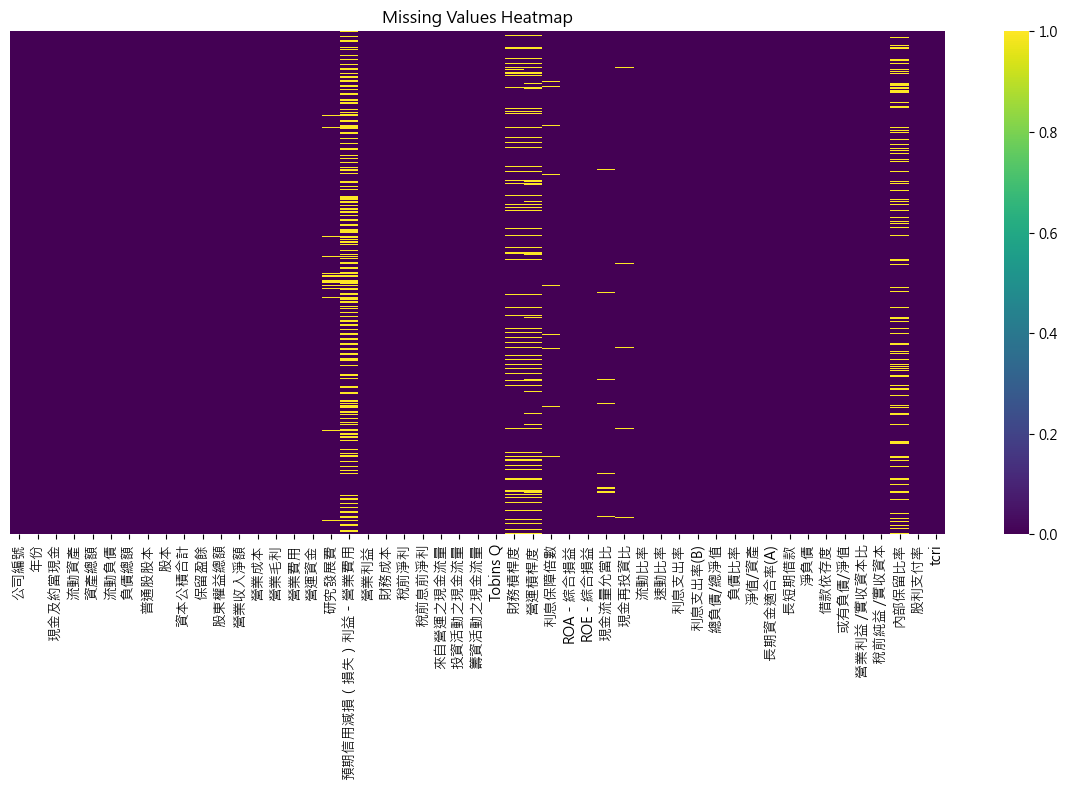

In [180]:
import seaborn as sns
import matplotlib
matplotlib.rc('font', family='Microsoft JhengHei')
# Missing values analysis
print("=== Missing Values Analysis ===")
missing_data = merged_data_final.isnull().sum()
missing_percentage = (merged_data_final.isnull().sum() / len(merged_data)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percentage.values
})

# show missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))

# Target variable missing values
target_missing = merged_data_final['tcri'].isnull().sum()
print(f"\nTarget variable (tcri) missing: {target_missing} ({target_missing/len(merged_data)*100:.2f}%)")

# Visualize missing values
plt.figure(figsize=(12, 8))
sns.heatmap(merged_data_final.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('missing_heat.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

=== 缺失值表格 - 兩欄布局（按缺失值排序） ===


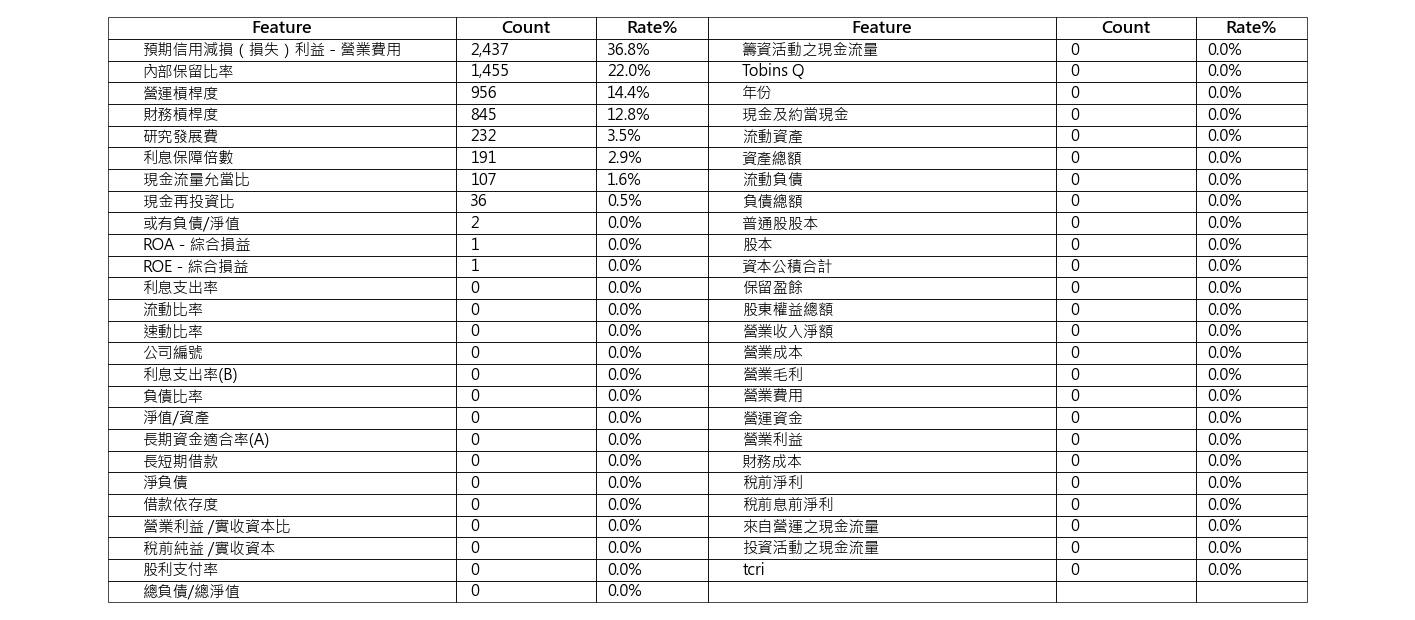

排序版缺失值表格已保存為 'missing_values_sorted_two_columns.png'


In [178]:
missing_count = merged_data_final.isnull().sum()
missing_percentage = (merged_data_final.isnull().sum() / len(merged_data_final)) * 100

missing_df = pd.DataFrame({
    'Feature': merged_data_final.columns,
    'Missing_Count': missing_count,
    'Missing_Rate (%)': missing_percentage
})

missing_df_sorted = missing_df.sort_values('Missing_Count', ascending=False)

total_features = len(missing_df_sorted)
split_index = (total_features + 1) // 2

left_features = missing_df_sorted.iloc[:split_index].copy()
right_features = missing_df_sorted.iloc[split_index:].copy()

max_length = max(len(left_features), len(right_features))
while len(left_features) < max_length:
    left_features = pd.concat([left_features, pd.DataFrame([{'Feature': '', 'Missing_Count': '', 'Missing_Rate (%)': ''}])], ignore_index=True)
while len(right_features) < max_length:
    right_features = pd.concat([right_features, pd.DataFrame([{'Feature': '', 'Missing_Count': '', 'Missing_Rate (%)': ''}])], ignore_index=True)

cell_text = []
for i in range(max_length):
    left_row = left_features.iloc[i]
    right_row = right_features.iloc[i]
    cell_text.append([
        left_row['Feature'],
        f"{left_row['Missing_Count']:,}" if left_row['Missing_Count'] != '' else '',
        f"{left_row['Missing_Rate (%)']:.1f}%" if left_row['Missing_Rate (%)'] != '' else '',
        right_row['Feature'],
        f"{right_row['Missing_Count']:,}" if right_row['Missing_Count'] != '' else '',
        f"{right_row['Missing_Rate (%)']:.1f}%" if right_row['Missing_Rate (%)'] != '' else ''
    ])

plt.figure(figsize=(18, max(6, max_length * 0.3)))
table = plt.table(cellText=cell_text,
                 colLabels=['Feature', 'Count', 'Rate%', 'Feature', 'Count', 'Rate%'],
                 loc='center',
                 cellLoc='left',
                 colWidths=[0.25, 0.1, 0.08, 0.25, 0.1, 0.08],
                 edges='closed')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.3)

for key, cell in table.get_celld().items():
    cell.set_facecolor('none')
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    if key[0] == 0:  # 標題行
        cell.set_text_props(weight='bold', size=12)
    else:
        cell.set_text_props(size=11)

plt.axis('off')
fig = plt.gcf()
fig.patch.set_alpha(0.0)
ax = plt.gca()
ax.set_facecolor('none')

plt.savefig('missing_values_sorted_two_columns.png', 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300, 
            pad_inches=0.1,
            facecolor='none',
            edgecolor='none')

plt.show()

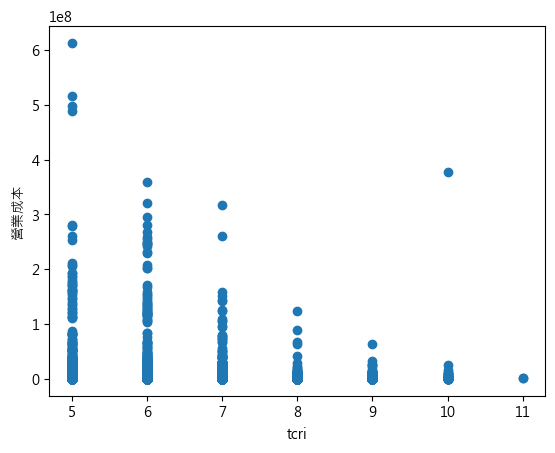

In [135]:
x = merged_data_final['tcri']
y = merged_data_final['營業成本']
plt.scatter(x, y)       
plt.xlabel('tcri')
plt.ylabel('營業成本')
plt.savefig('=test.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [146]:
merged_data_final2 = merged_data_final.dropna(subset=['tcri'])
merged_data_final2

<Figure size 640x480 with 0 Axes>

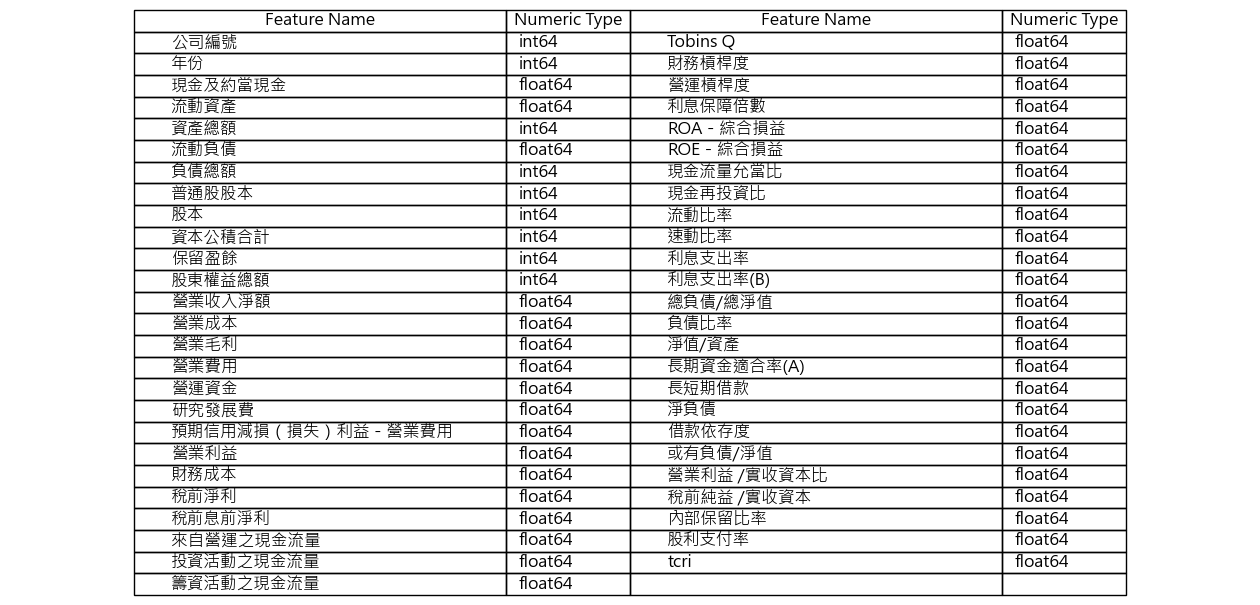

In [179]:
dtype_df = pd.DataFrame({
    'Feature': merged_data_final.columns,
    'Data_Type': merged_data_final.dtypes.astype(str)
})

def extract_numeric_type(dtype_str):
    if 'float' in dtype_str:
        return 'float64'
    elif 'int' in dtype_str:
        return 'int64'
    elif 'object' in dtype_str:
        return 'object'
    elif 'bool' in dtype_str:
        return 'bool'
    else:
        return dtype_str

dtype_df['Numeric_Type'] = dtype_df['Data_Type'].apply(extract_numeric_type)

total_features = len(dtype_df)
split_index = (total_features + 1) // 2

left_features = dtype_df.iloc[:split_index].copy()
right_features = dtype_df.iloc[split_index:].copy()

max_length = max(len(left_features), len(right_features))
while len(left_features) < max_length:
    left_features = pd.concat([left_features, pd.DataFrame([{'Feature': '', 'Numeric_Type': ''}])], ignore_index=True)
while len(right_features) < max_length:
    right_features = pd.concat([right_features, pd.DataFrame([{'Feature': '', 'Numeric_Type': ''}])], ignore_index=True)

cell_text = []
for i in range(max_length):
    left_row = left_features.iloc[i]
    right_row = right_features.iloc[i]
    cell_text.append([
        left_row['Feature'],
        left_row['Numeric_Type'],
        right_row['Feature'], 
        right_row['Numeric_Type']
    ])


plt.figure(figsize=(16, max(6, max_length * 0.25)))
table = plt.table(cellText=cell_text,
                 colLabels=['Feature Name', 'Numeric Type', 'Feature Name', 'Numeric Type'],
                 loc='center',
                 cellLoc='left',
                 colWidths=[0.3, 0.1, 0.3, 0.1]
                 )

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.3)

for i in range(4):
    if i < 2:
        table[(0, i)].set_facecolor('none')  
    else:
        table[(0, i)].set_facecolor('none') 

plt.axis('off')

fig = plt.gcf()
fig.patch.set_alpha(0.0)  
ax = plt.gca()
ax.set_facecolor('none') 

for key, cell in table.get_celld().items():
    if key[0] > 0:  
        cell.set_facecolor('none')

plt.savefig('feature_data_types.png', 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300, 
            pad_inches=0.1,
            facecolor='none',   
            edgecolor='none')   

### 移除特殊字

In [142]:
def clean_numeric(value):
    if pd.isna(value) or value == '--':
        return np.nan
    if isinstance(value, str):
        value = value.replace(',', '').replace(' ', '')
        try:
            return float(value)
        except:
            return np.nan
    return value

numeric_columns = merged_data_final.select_dtypes(include=[object]).columns
for col in numeric_columns:
    merged_data_final[col] = merged_data_final[col].apply(clean_numeric)

merged_data_final.shape

(6624, 51)

### 計算相關性

In [143]:
correlation_matrix = merged_data_final.select_dtypes(include=[np.number]).corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = abs(correlation_matrix.iloc[i, j])
        if corr_value > 0.5:  # cor
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in high_corr_pairs[:30]:  # show 30
    print(f"{pair[0]} vs {pair[1]}: {pair[2]:.3f}")

負債比率 vs 淨值/資產: 1.000
普通股股本 vs 股本: 0.998
內部保留比率 vs 股利支付率: 0.997
稅前淨利 vs 稅前息前淨利: 0.996
營業收入淨額 vs 營業成本: 0.988
資產總額 vs 負債總額: 0.973
營業利益 vs 稅前息前淨利: 0.948
總負債/總淨值 vs 借款依存度: 0.945
營業利益 vs 稅前淨利: 0.945
流動資產 vs 流動負債: 0.941
營業毛利 vs 營業利益: 0.911
營業毛利 vs 稅前息前淨利: 0.898
長短期借款 vs 淨負債: 0.891
財務成本 vs 長短期借款: 0.886
營業毛利 vs 稅前淨利: 0.878
ROA－綜合損益 vs ROE－綜合損益: 0.877
營業利益 /實收資本比 vs 稅前純益 /實收資本: 0.876
普通股股本 vs 股東權益總額: 0.873
股本 vs 股東權益總額: 0.867
營業毛利 vs 來自營運之現金流量: 0.842
營業收入淨額 vs 營業費用: 0.822
資本公積合計 vs 股東權益總額: 0.816
營業費用 vs 研究發展費: 0.811
營業成本 vs 營業費用: 0.801
保留盈餘 vs 股東權益總額: 0.787
現金及約當現金 vs 股東權益總額: 0.784
營業利益 vs 來自營運之現金流量: 0.781
現金及約當現金 vs 營業收入淨額: 0.764
現金及約當現金 vs 資產總額: 0.759
資本公積合計 vs 研究發展費: 0.759


### 熱力圖

C:\Users\jack9\python\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()
C:\Users\jack9\AppData\Local\Temp\ipykernel_21596\3504265363.py:13: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig('merged_heat.png', transparent=True, bbox_inches='tight', dpi=300)
C:\Users\jack9\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


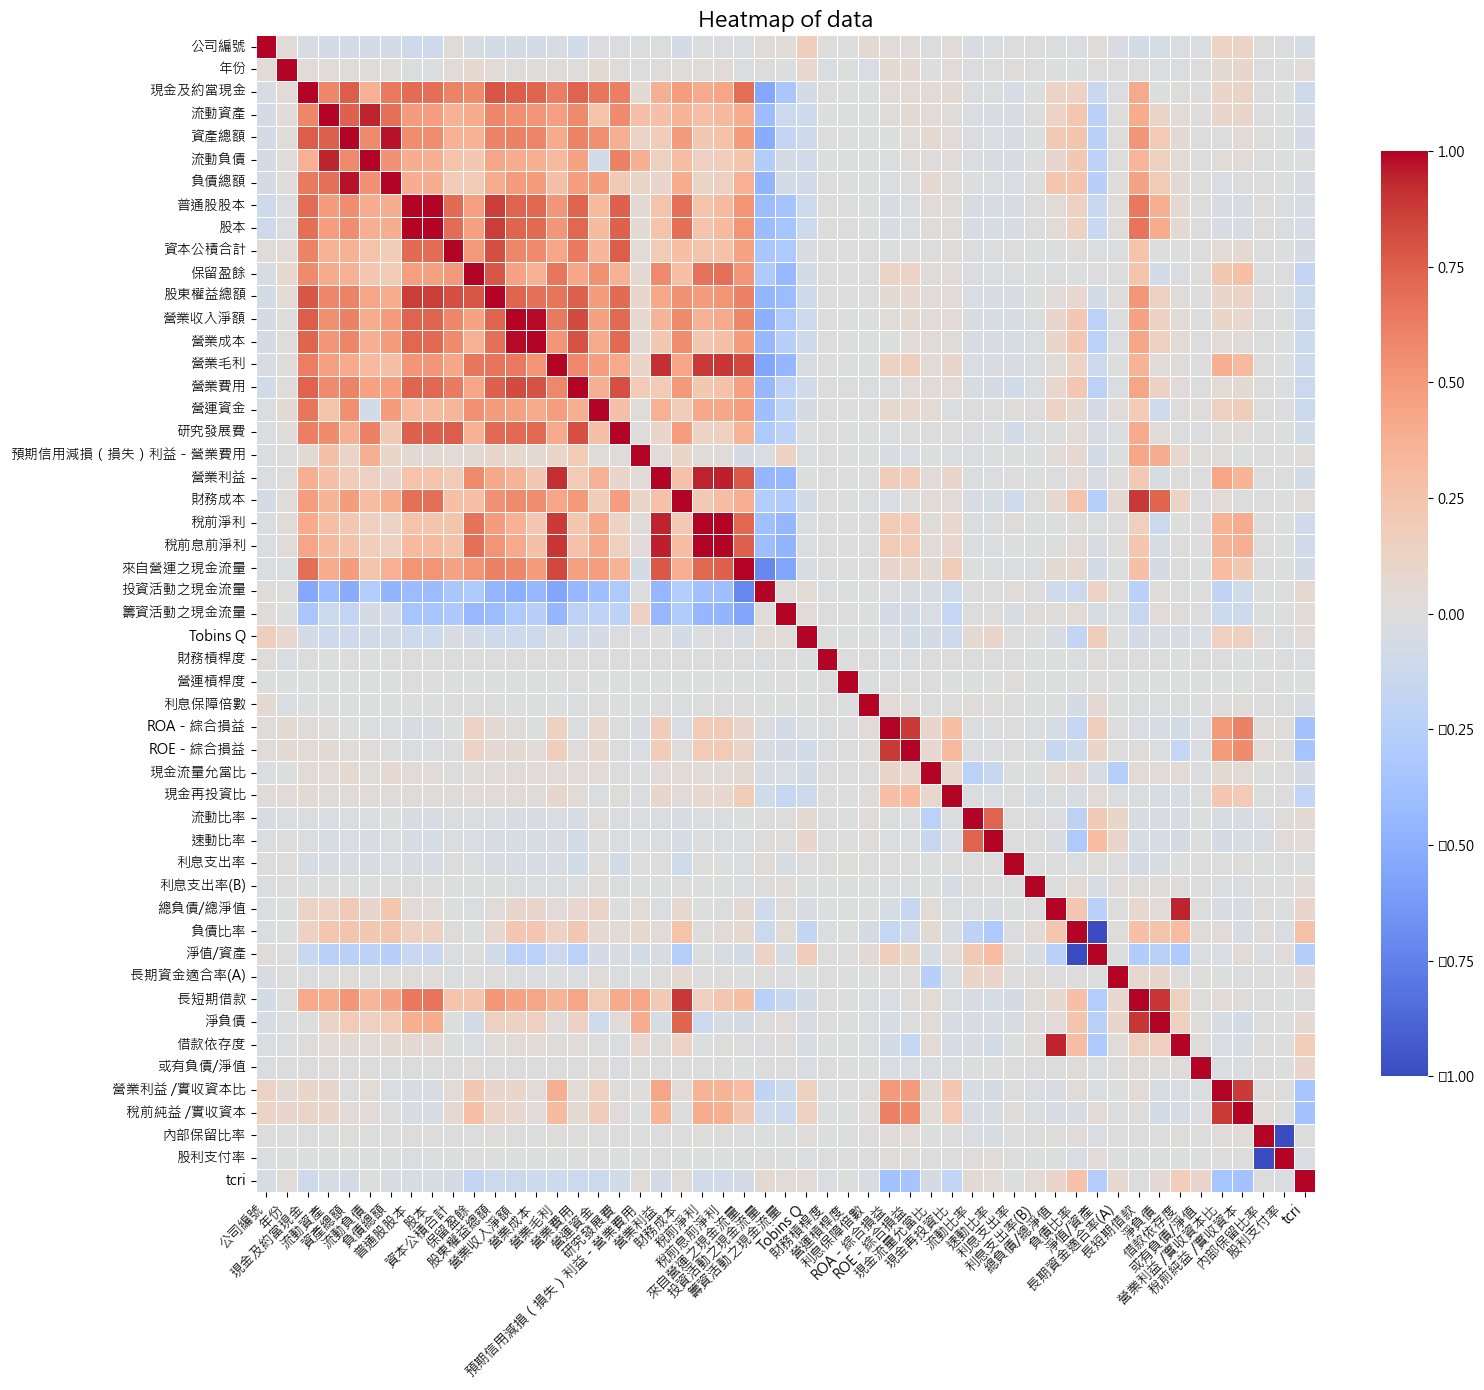

In [181]:
import seaborn as sns
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
           annot=False, 
           cmap='coolwarm', 
           center=0,
           linewidths=0.5,
           cbar_kws={"shrink": 0.8})
plt.title('Heatmap of data', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('merged_heat.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

### 相關性 絕對值

In [56]:
feature_importance = correlation_matrix.abs().mean().sort_values(ascending=False)

for i, (feature, score) in enumerate(feature_importance.items()):
    print(f"{i+1:2d}. {feature}: {score:.3f}")

 1. 股東權益總額: 0.325
 2. 營業收入淨額: 0.316
 3. 現金及約當現金: 0.315
 4. 營業毛利: 0.311
 5. 普通股股本: 0.301
 6. 股本: 0.301
 7. 營業費用: 0.298
 8. 來自營運之現金流量: 0.291
 9. 營業成本: 0.290
10. 資產總額: 0.287
11. 流動資產: 0.272
12. 財務成本: 0.263
13. 保留盈餘: 0.259
14. 長短期借款: 0.258
15. 稅前息前淨利: 0.249
16. 研究發展費: 0.238
17. 負債總額: 0.237
18. 稅前淨利: 0.234
19. 投資活動之現金流量: 0.229
20. 營業利益: 0.229
21. 資本公積合計: 0.225
22. 營運資金: 0.225
23. 流動負債: 0.214
24. 總負債/總淨值: 0.176
25. 負債比率: 0.168
26. 淨值/資產: 0.168
27. 籌資活動之現金流量: 0.167
28. 稅前純益 /實收資本: 0.152
29. 營業利益 /實收資本比: 0.150
30. 借款依存度: 0.149
31. 淨負債: 0.143
32. ROA－綜合損益: 0.120
33. tcri: 0.120
34. ROE－綜合損益: 0.120
35. Tobins Q: 0.088
36. 預期信用減損（損失）利益－營業費用: 0.087
37. 速動比率: 0.080
38. 現金再投資比: 0.076
39. 流動比率: 0.070
40. 公司編號: 0.064
41. 現金流量允當比: 0.061
42. 內部保留比率: 0.049
43. 股利支付率: 0.045
44. 長期資金適合率(A): 0.044
45. 年份: 0.042
46. 利息支出率: 0.039
47. 或有負債/淨值: 0.032
48. 利息支出率(B): 0.031
49. 利息保障倍數: 0.031
50. 財務槓桿度: 0.023
51. 營運槓桿度: 0.022


<Figure size 1600x1600 with 0 Axes>

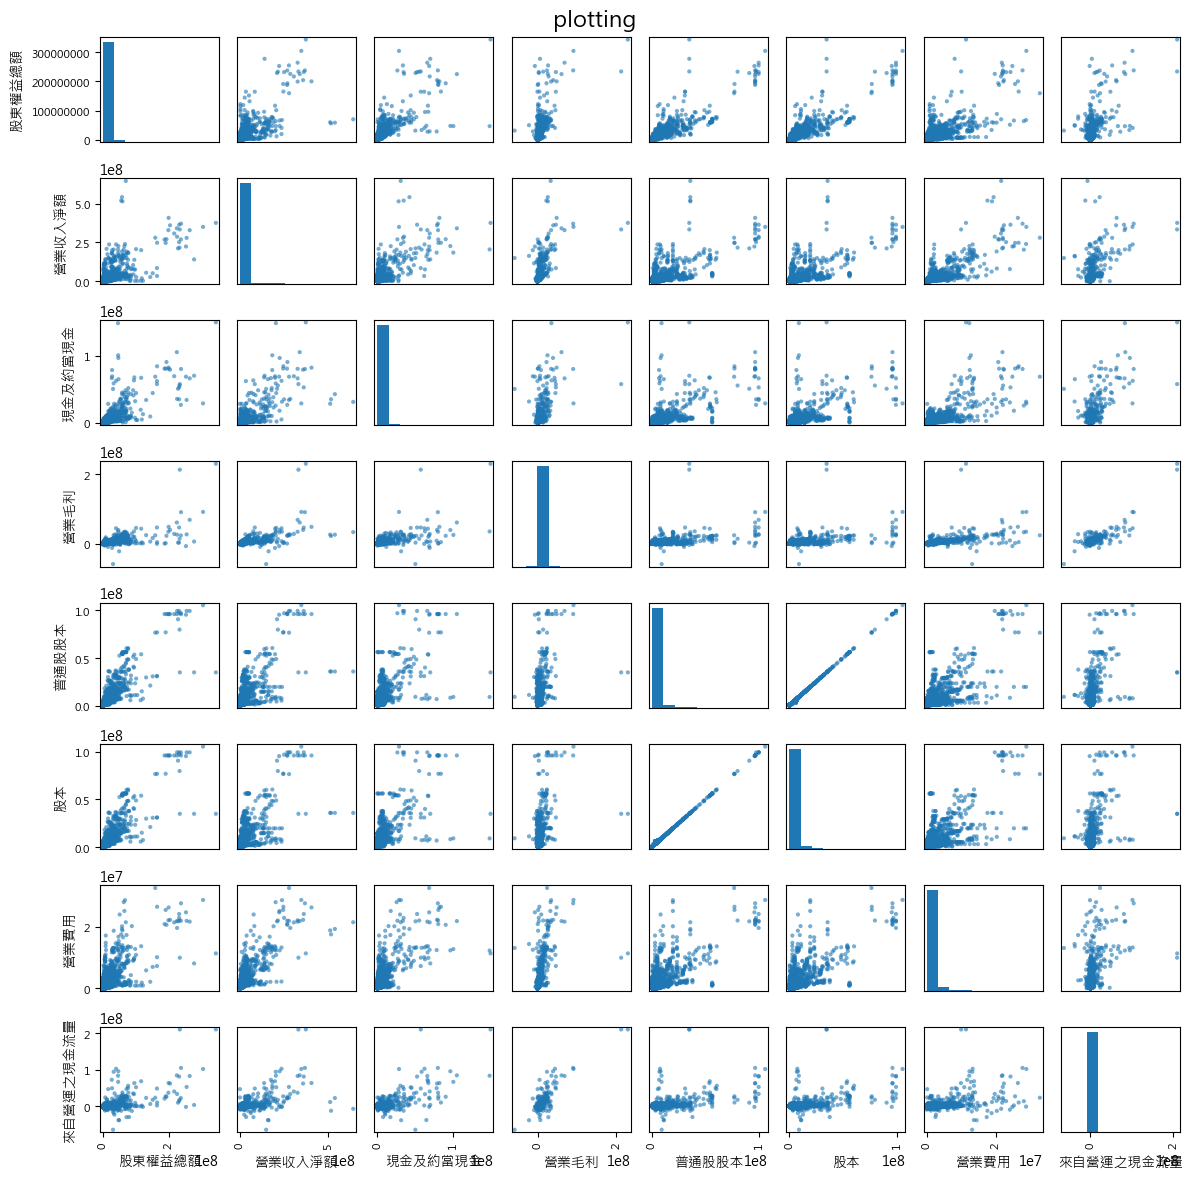

In [57]:
top_features = feature_importance.head(8).index.tolist()
if len(top_features) >= 3:
    from pandas.plotting import scatter_matrix
    
    plt.figure(figsize=(16, 16))
    scatter_matrix(merged_data_final[top_features], 
                  alpha=0.6, 
                  figsize=(12, 12), 
                  diagonal='hist')
    plt.suptitle('plotting', fontsize=16)
    plt.tight_layout()
    plt.show()

普通股股本 vs 股本: 1.000
稅前淨利 vs 稅前息前淨利: 0.996
營業收入淨額 vs 營業成本: 0.987
資產總額 vs 負債總額: 0.973
營業利益 vs 稅前息前淨利: 0.947
營業利益 vs 稅前淨利: 0.945
流動資產 vs 流動負債: 0.941
營業毛利 vs 營業利益: 0.911
營業毛利 vs 稅前息前淨利: 0.898
ROA－綜合損益 vs ROE－綜合損益: 0.894
長短期借款 vs 淨負債: 0.881
營業毛利 vs 稅前淨利: 0.878
財務成本 vs 長短期借款: 0.876
營業利益 /實收資本比 vs 稅前純益 /實收資本: 0.875
普通股股本 vs 股東權益總額: 0.872
股本 vs 股東權益總額: 0.872
營業毛利 vs 來自營運之現金流量: 0.842
營業收入淨額 vs 營業費用: 0.820
資本公積合計 vs 股東權益總額: 0.812
營業費用 vs 研究發展費: 0.808
營業成本 vs 營業費用: 0.798
保留盈餘 vs 股東權益總額: 0.796
營業利益 vs 來自營運之現金流量: 0.783
現金及約當現金 vs 股東權益總額: 0.780
現金及約當現金 vs 資產總額: 0.760
現金及約當現金 vs 營業收入淨額: 0.759
資本公積合計 vs 研究發展費: 0.751
稅前息前淨利 vs 來自營運之現金流量: 0.745
流動資產 vs 資產總額: 0.744
股東權益總額 vs 營業費用: 0.739


C:\Users\jack9\AppData\Local\Temp\ipykernel_21596\3376977765.py:31: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\jack9\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


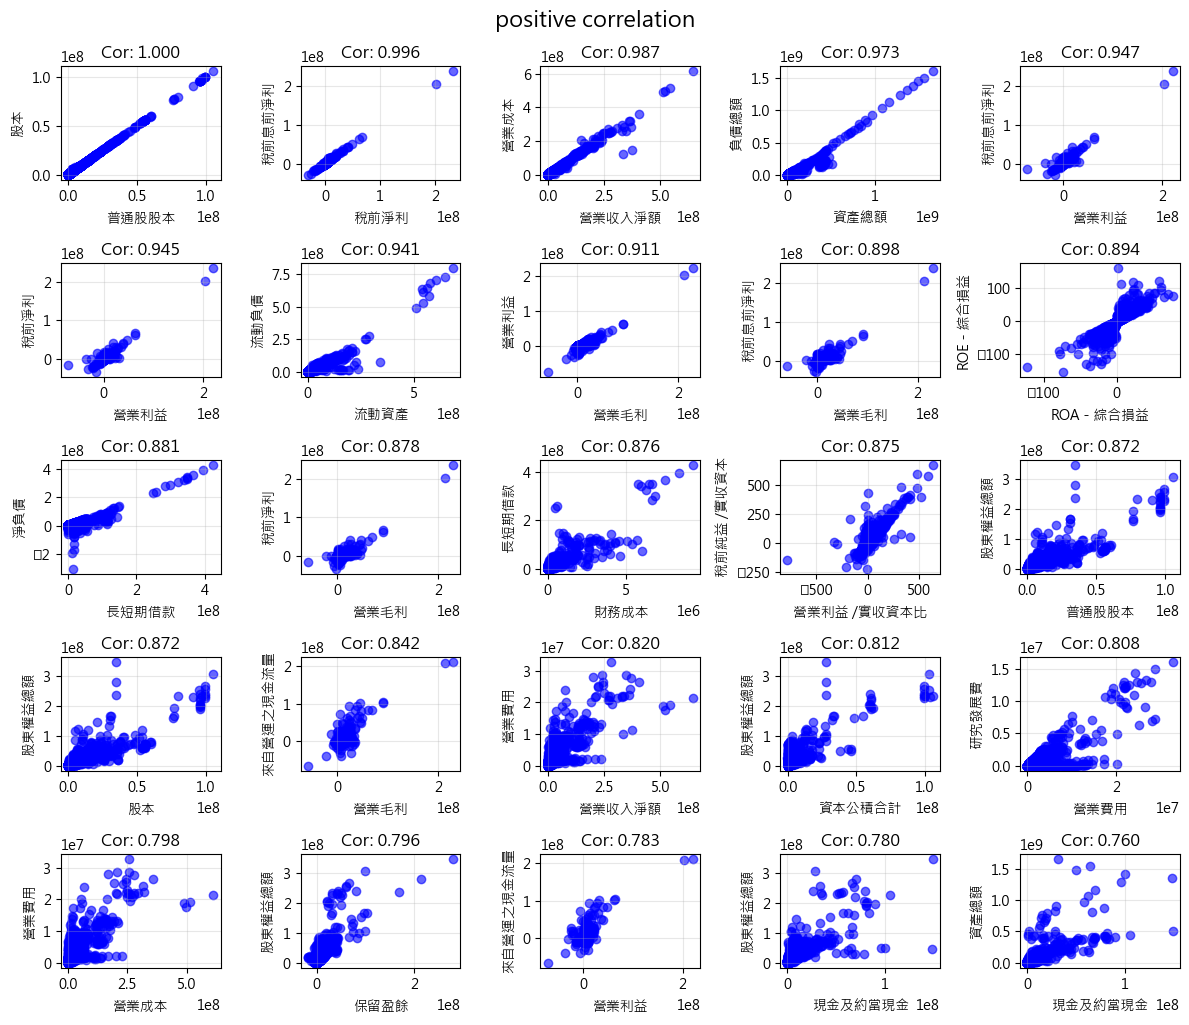

In [58]:
positive_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value > 0.3:  # cor>0.5
            positive_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

positive_corr_pairs.sort(key=lambda x: x[2], reverse=True)# 從最高到最低

for pair in positive_corr_pairs[:30]:  # show 30
    print(f"{pair[0]} vs {pair[1]}: {pair[2]:.3f}")

if positive_corr_pairs:
    top_positive_pairs = positive_corr_pairs[:25]
    
    fig, axes = plt.subplots(5, 5, figsize=(12, 10))
    axes = axes.ravel()
    
    for idx, (feature1, feature2, corr_value) in enumerate(top_positive_pairs):
        if idx < 25:  # 25
            axes[idx].scatter(merged_data_final[feature1], merged_data_final[feature2], alpha=0.6, color='blue')
            axes[idx].set_xlabel(feature1)
            axes[idx].set_ylabel(feature2)
            axes[idx].set_title(f'Cor: {corr_value:.3f}')
            axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('positive correlation', fontsize=16, y=1.02)
    plt.show()

### Categorical (NOT YET)


3. CATEGORICAL VARIABLES FREQUENCY

公司 Frequency Distribution:
Total unique values: 1030
公司
1101 台泥        11
4106 雃博        11
3669 圓展        11
3673 TPK-KY    11
3679 新至陞       11
3686 達能        11
3694 海華        11
3701 大眾控       11
3702 大聯大       11
3703 欣陸        11
Name: count, dtype: int64

年/月 Frequency Distribution:
Total unique values: 11
年/月
2024/12    1029
2022/12    1029
2023/12    1029
2021/12    1028
2020/12    1023
2019/12    1013
2018/12     998
2017/12     986
2016/12     975
2015/12     959
Name: count, dtype: int64


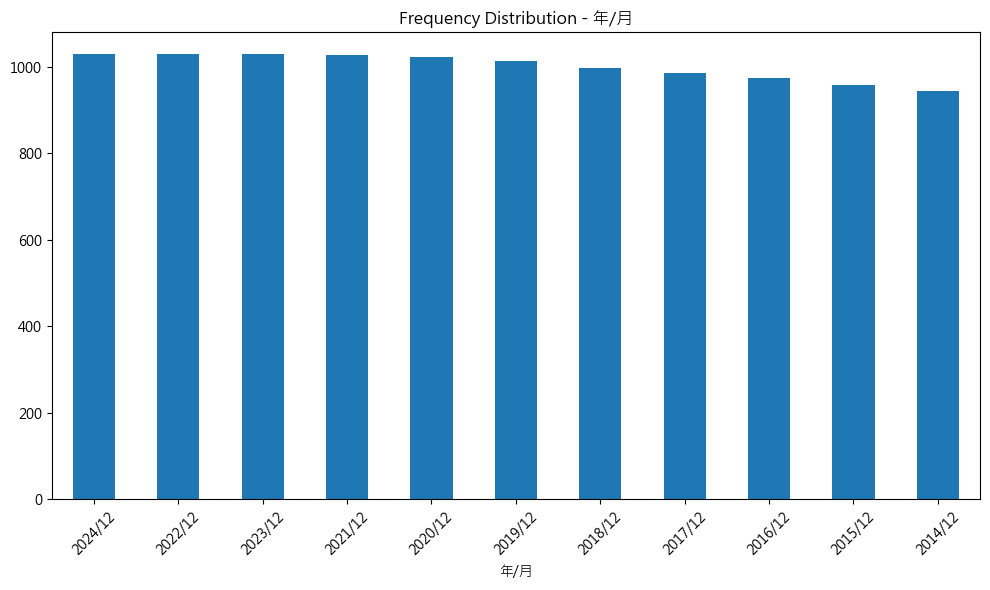


合併(Y/N) Frequency Distribution:
Total unique values: 2
合併(Y/N)
Y    10378
N      636
Name: count, dtype: int64


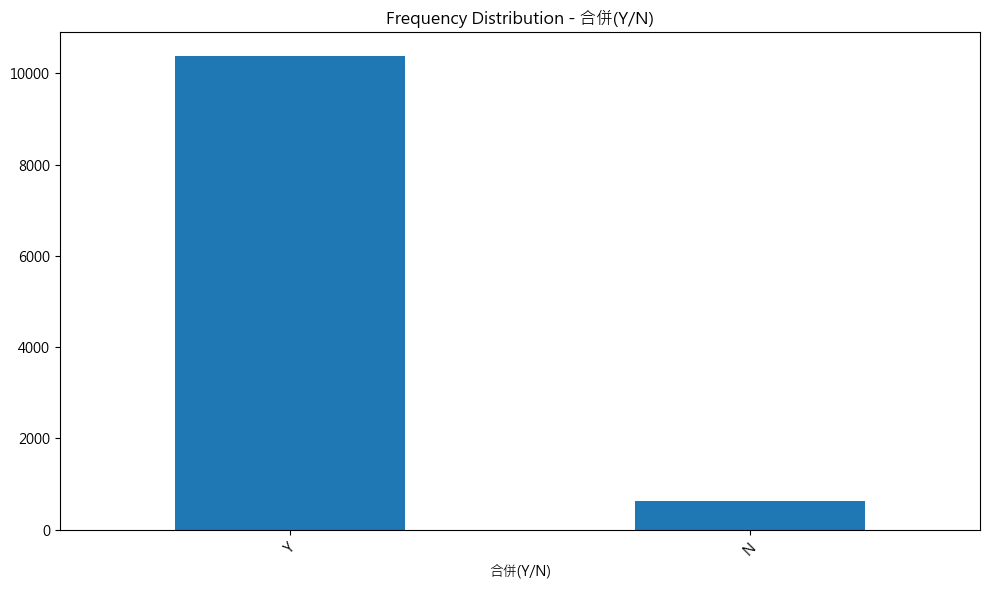


幣別 Frequency Distribution:
Total unique values: 1
幣別
NTD    11014
Name: count, dtype: int64


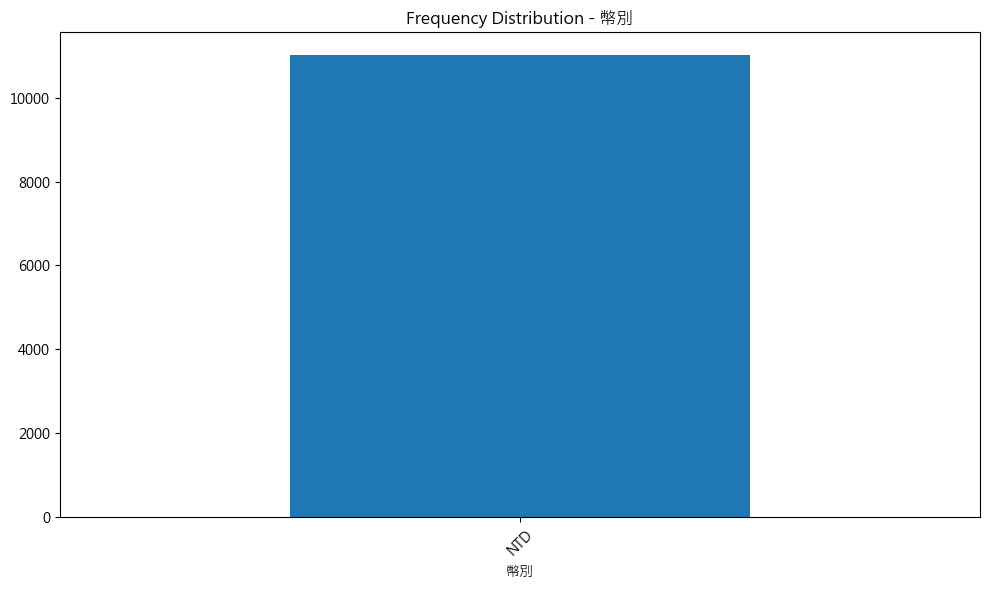


  現金及約當現金 Frequency Distribution:
Total unique values: 11000
  現金及約當現金
101,579      2
239,601      2
616,436      2
520,648      2
373,909      2
1,468,956    2
573,450      2
491,638      2
255,482      2
994,321      2
Name: count, dtype: int64

流動資產 Frequency Distribution:
Total unique values: 10672
流動資產
-            341
2,531,015      2
1,938,505      2
1,779,939      1
1,466,895      1
2,306,995      1
2,357,299      1
2,027,262      1
1,962,845      1
2,115,234      1
Name: count, dtype: int64

資產總額 Frequency Distribution:
Total unique values: 11014
資產總額
593,413,647    1
6,916,866      1
3,030,217      1
1,563,707      1
7,581,853      1
5,744,361      1
8,038,168      1
7,910,882      1
4,394,531      1
7,173,226      1
Name: count, dtype: int64

流動負債 Frequency Distribution:
Total unique values: 10668
流動負債
-            341
3,221,457      2
2,655,411      2
238,654        2
1,096,038      2
1,077,121      2
760,497        2
989,039        1
1,370,297      1
632,369        1
Name

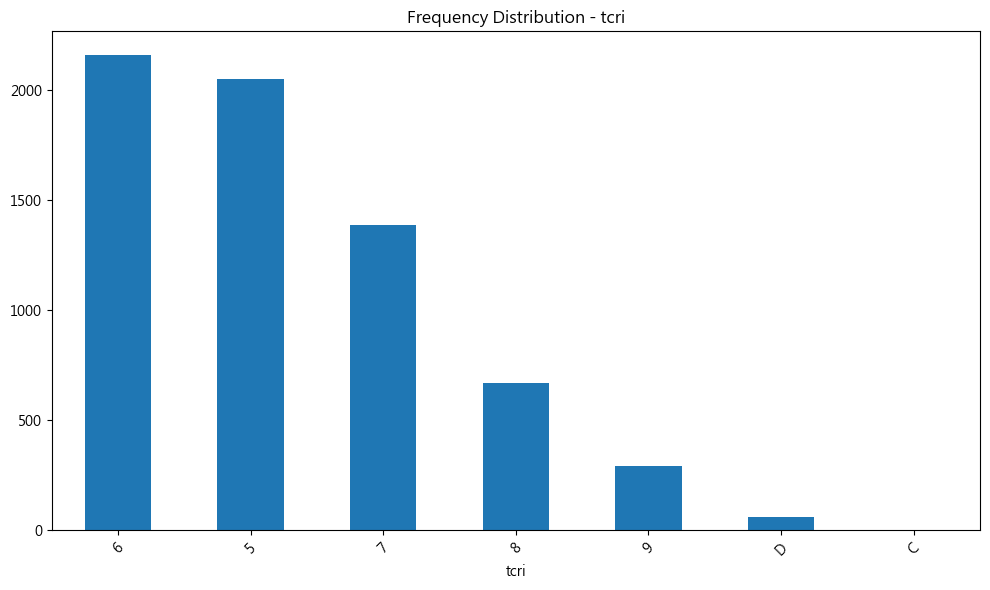

In [11]:
print("\n" + "="*50)
print("3. CATEGORICAL VARIABLES FREQUENCY")
print("="*50)

categorical_vars = merged_data.select_dtypes(include=['object']).columns.tolist()

if categorical_vars:
    for col in categorical_vars:
        print(f"\n{col} Frequency Distribution:")
        freq = merged_data[col].value_counts()
        print(f"Total unique values: {len(freq)}")
        print(freq.head(10))  
        
        if len(freq) <= 20:  
            plt.figure(figsize=(10, 6))
            freq.plot(kind='bar')
            plt.title(f'Frequency Distribution - {col}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
else:
    print("No categorical variables found in the dataset.")